In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [ ]:
n = 100000
np.random.seed(42)

data = {
    "Customer_ID": range(1, n+1),
    "Age": np.random.randint(18, 71, n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "Tenure": np.random.randint(0, 11, n),
    "Balance": np.random.randint(0, 200001, n),
    "CreditScore": np.random.randint(300, 901, n),
    "EstimatedSalary": np.random.randint(10000, 150001, n),
    "NumOfProducts": np.random.randint(1, 5, n),
    "IsActiveMember": np.random.choice(["Yes", "No"], n)
}

df = pd.DataFrame(data)

df.head()

,Customer_ID,Age,Gender,Tenure,Balance,CreditScore,EstimatedSalary,NumOfProducts,IsActiveMember
0,1,56,Female,3,138803,718,121992,4,No
1,2,69,Male,1,174102,534,125877,2,No
2,3,46,Female,10,90135,653,39062,2,Yes
3,4,32,Male,6,160284,787,66364,2,Yes
4,5,60,Female,6,24298,681,116045,2,Yes


In [ ]:
def generate_churn(row):
    score = 0

    if row["CreditScore"] < 500:
        score += 1
    if row["Tenure"] < 3:
        score += 1
    if row["IsActiveMember"] == "No":
        score += 1
    if row["Balance"] > 100000 and row["IsActiveMember"] == "No":
        score += 1

    return 1 if score >= 2 else 0

df["Churn"] = df.apply(generate_churn, axis=1)

df.head()

,Customer_ID,Age,Gender,Tenure,Balance,CreditScore,EstimatedSalary,NumOfProducts,IsActiveMember,Churn
0,1,56,Female,3,138803,718,121992,4,No,1
1,2,69,Male,1,174102,534,125877,2,No,1
2,3,46,Female,10,90135,653,39062,2,Yes,0
3,4,32,Male,6,160284,787,66364,2,Yes,0
4,5,60,Female,6,24298,681,116045,2,Yes,0


In [ ]:
df.info()

df.isnull().sum()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   Customer_ID      100000 non-null  int64 
 1   Age              100000 non-null  int64 
 2   Gender           100000 non-null  object
 3   Tenure           100000 non-null  int64 
 4   Balance          100000 non-null  int64 
 5   CreditScore      100000 non-null  int64 
 6   EstimatedSalary  100000 non-null  int64 
 7   NumOfProducts    100000 non-null  int64 
 8   IsActiveMember   100000 non-null  object
 9   Churn            100000 non-null  int64 
dtypes: int64(8), object(2)
memory usage: 7.6+ MB


,Customer_ID,Age,Tenure,Balance,CreditScore,EstimatedSalary,NumOfProducts,Churn
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,43.984060,4.988760,99742.233670,599.942750,79959.021360,2.501980,0.424500
std,28867.657797,15.251827,3.163744,57670.541911,173.269555,40445.277417,1.117734,0.494269
min,1.000000,18.000000,0.000000,0.000000,300.000000,10000.000000,1.000000,0.000000
25%,25000.750000,31.000000,2.000000,49819.000000,450.000000,45009.000000,2.000000,0.000000
50%,50000.500000,44.000000,5.000000,99729.000000,599.000000,80008.500000,3.000000,0.000000
75%,75000.250000,57.000000,8.000000,149691.250000,750.000000,114916.000000,4.000000,1.000000
max,100000.000000,70.000000,10.000000,200000.000000,900.000000,150000.000000,4.000000,1.000000


In [ ]:
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})
df["IsActiveMember"] = df["IsActiveMember"].map({"No": 0, "Yes": 1})

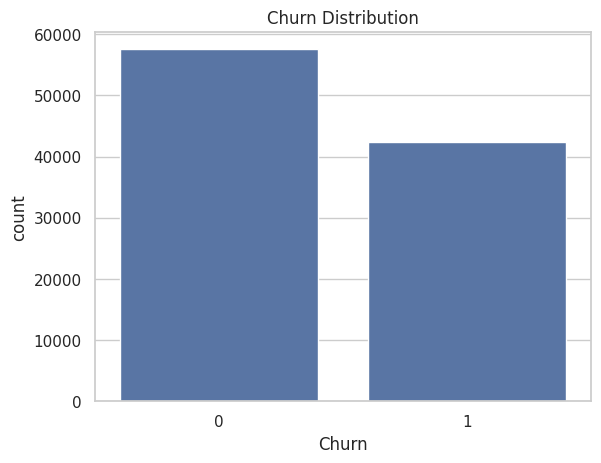

In [ ]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

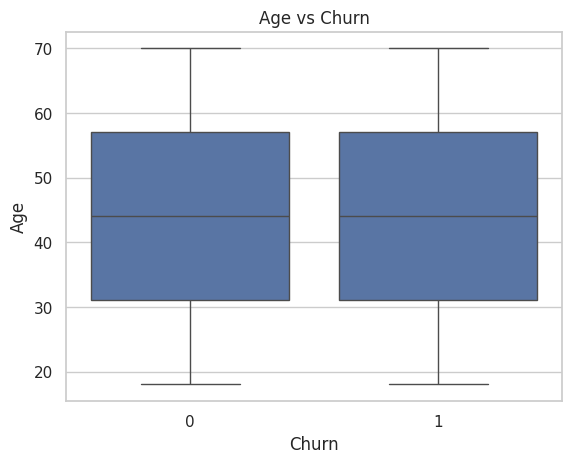

In [ ]:
plt.figure()
sns.boxplot(x="Churn", y="Age", data=df)
plt.title("Age vs Churn")
plt.show()

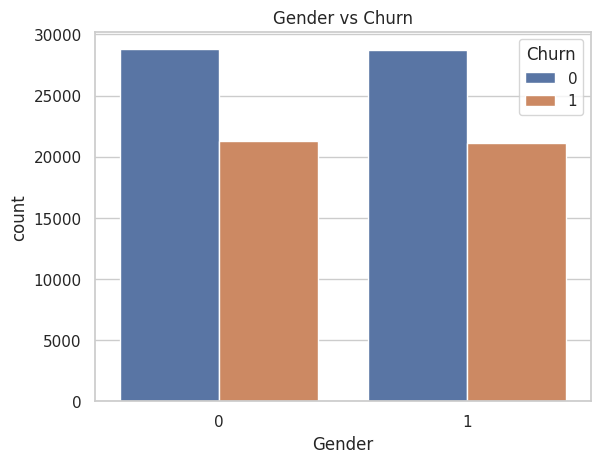

In [ ]:
sns.countplot(x="Gender", hue="Churn", data=df)
plt.title("Gender vs Churn")
plt.show()

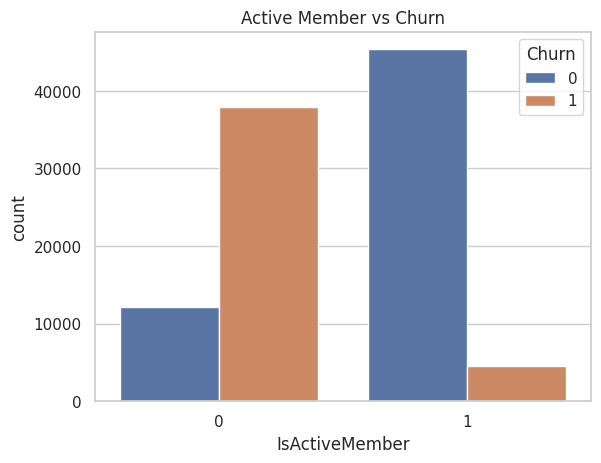

In [ ]:
sns.countplot(x="IsActiveMember", hue="Churn", data=df)
plt.title("Active Member vs Churn")
plt.show()

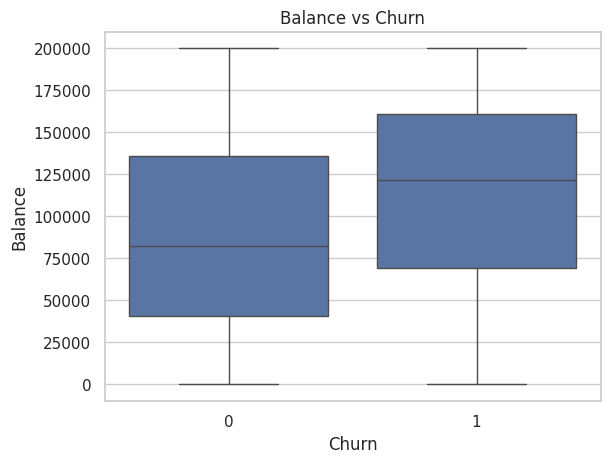

In [ ]:
plt.figure()
sns.boxplot(x="Churn", y="Balance", data=df)
plt.title("Balance vs Churn")
plt.show()

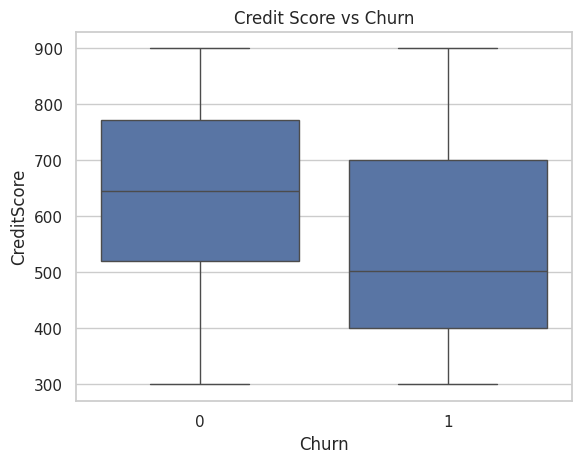

In [ ]:
plt.figure()
sns.boxplot(x="Churn", y="CreditScore", data=df)
plt.title("Credit Score vs Churn")
plt.show()

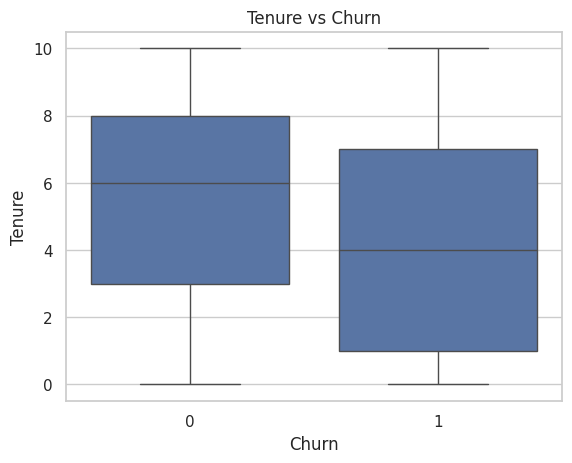

In [ ]:
plt.figure()
sns.boxplot(x="Churn", y="Tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

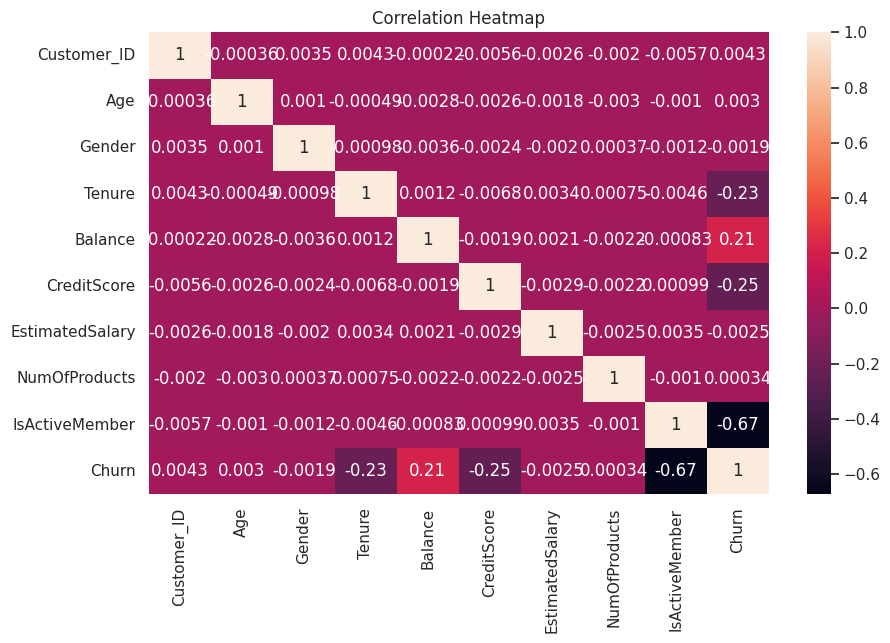

In [ ]:
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
high_churn = df[df["Churn"] == 1]

print("Total Churn Customers:", len(high_churn))
high_churn.head()

Total Churn Customers: 42450


,Customer_ID,Age,Gender,Tenure,Balance,CreditScore,EstimatedSalary,NumOfProducts,IsActiveMember,Churn
0,1,56,1,3,138803,718,121992,4,0,1
1,2,69,0,1,174102,534,125877,2,0,1
5,6,25,0,4,118607,312,70553,2,0,1
6,7,38,0,6,157186,888,102827,3,0,1
13,14,70,1,1,172127,495,36126,2,1,1
